# Laboratorio 2   
## Regresión lineal y regresión logística paso a paso

**Curso:** Machine Learning  
**Modalidad:** Google Colab / Jupyter Notebook  
**Objetivo general:** aprender a construir, entrenar y evaluar un modelo de **regresión lineal** para predecir una variable continua y un modelo de **regresión logística** para clasificar una variable binaria.

---

### ¿Qué contiene este laboratorio?
1. **Explicación paso a paso** de cada bloque.
2. **4 datasets** distintos, uno por sección:
   - `datasets/lab2_seccion_A.csv`
   - `datasets/lab2_seccion_B.csv`
   - `datasets/lab2_seccion_C.csv`
   - `datasets/lab2_seccion_D.csv`
3. Actividad guiada + preguntas de interpretación.
4. Un flujo de trabajo parecido al del **Laboratorio 1**:  
   **entender → cargar → explorar → preparar → modelar → evaluar → interpretar**.


## 1. Instrucciones de uso

Cada sección debe trabajar con su propio dataset.

- **Sección 1** → `lab2_seccion_A.csv`
- **Sección 2** → `lab2_seccion_B.csv`
- **Sección 3** → `lab2_seccion_C.csv`
- **Sección 4** → `lab2_seccion_D.csv`

> Para Google Colab, sube la carpeta del laboratorio o colócala en tu Google Drive para que el notebook pueda encontrar los archivos.


In [70]:
# ============================================================
# PASO 0. Importar librerías
# ============================================================
# En este paso cargamos las herramientas que usaremos durante
# todo el laboratorio.
# - pandas y numpy: manipulación de datos
# - matplotlib / seaborn: visualización
# - sklearn: modelos y métricas
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)


## 2. Seleccionar el dataset de la sección

Aquí definimos cuál archivo va a usar cada grupo.

### ¿Por qué hacemos esto?
Porque el mismo laboratorio será usado por **4 secciones**, pero cada una tendrá un archivo distinto.  
Así evitamos que todas las secciones trabajen exactamente con los mismos registros, aunque el procedimiento siga siendo el mismo.


In [71]:
# Cambia esta variable según tu sección:
# A, B, C o D

SECCION = "A"

ruta_dataset = Path("datasets") / f"lab2_seccion_{SECCION}.csv"
print("Archivo seleccionado:", ruta_dataset)


Archivo seleccionado: datasets/lab2_seccion_A.csv


In [72]:
# ============================================================
# PASO 1. Cargar el dataset
# ============================================================
# Leemos el archivo CSV y guardamos el contenido en un DataFrame.
# El DataFrame es la estructura principal de trabajo en pandas.
# ============================================================

df = pd.read_csv("/content/drive/MyDrive/datasets/lab2_seccion_A.csv")
df.head()


,id_estudiante,seccion,horas_estudio_semana,asistencia_pct,tareas_entregadas,promedio_quices,nota_proyecto,participacion_clase,uso_plataforma_min_semana,tutorias_asistidas,promedio_prev,nota_final,aprobado
0,A-001,A,5.6,73.2,10,69.1,86.7,8,87,5,71.7,62.5,0
1,A-002,A,1.9,93.9,8,75.2,61.5,8,139,1,76.2,52.5,0
2,A-003,A,9.8,80.1,8,68.3,70.6,7,261,3,74.6,65.3,0
3,A-004,A,10.2,92.5,8,71.6,61.8,8,117,3,80.2,68.6,0
4,A-005,A,7.1,88.3,10,76.0,60.8,9,42,0,70.5,61.8,0


In [73]:
from google.colab import data_table
data_table.DataTable(df, include_index=False, num_rows_per_page=10)

,id_estudiante,seccion,horas_estudio_semana,asistencia_pct,tareas_entregadas,promedio_quices,nota_proyecto,participacion_clase,uso_plataforma_min_semana,tutorias_asistidas,promedio_prev,nota_final,aprobado
0,A-001,A,5.6,73.2,10,69.1,86.7,8,87,5,71.7,62.5,0
1,A-002,A,1.9,93.9,8,75.2,61.5,8,139,1,76.2,52.5,0
2,A-003,A,9.8,80.1,8,68.3,70.6,7,261,3,74.6,65.3,0
3,A-004,A,10.2,92.5,8,71.6,61.8,8,117,3,80.2,68.6,0
4,A-005,A,7.1,88.3,10,76.0,60.8,9,42,0,70.5,61.8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,A-176,A,9.4,87.9,10,88.9,77.4,5,255,3,72.2,73.5,1
176,A-177,A,13.5,81.7,8,67.0,83.7,6,63,3,75.4,78.5,1
177,A-178,A,4.4,85.1,9,80.4,67.0,7,149,3,80.5,73.3,1
178,A-179,A,5.5,75.5,8,62.7,64.2,6,169,5,75.3,66.0,0


In [74]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Comprender las variables

Antes de modelar, debemos saber **qué significa cada columna**.

### Variables predictoras
- `horas_estudio_semana`: horas de estudio por semana.
- `asistencia_pct`: porcentaje de asistencia.
- `tareas_entregadas`: cantidad de tareas entregadas.
- `promedio_quices`: promedio de quices.
- `nota_proyecto`: nota del proyecto.
- `participacion_clase`: nivel de participación.
- `uso_plataforma_min_semana`: tiempo de uso de la plataforma.
- `tutorias_asistidas`: número de tutorías.
- `promedio_prev`: promedio académico previo.

### Variables objetivo
- `nota_final`: variable numérica continua → se usa en **regresión lineal**.
- `aprobado`: variable binaria (0 o 1) → se usa en **regresión logística**.


In [75]:
# Revisemos tamaño, columnas y tipos de datos
print("Filas y columnas:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)


Filas y columnas: (180, 13)

Columnas:
['id_estudiante', 'seccion', 'horas_estudio_semana', 'asistencia_pct', 'tareas_entregadas', 'promedio_quices', 'nota_proyecto', 'participacion_clase', 'uso_plataforma_min_semana', 'tutorias_asistidas', 'promedio_prev', 'nota_final', 'aprobado']

Tipos de datos:
id_estudiante                 object
seccion                       object
horas_estudio_semana         float64
asistencia_pct               float64
tareas_entregadas              int64
promedio_quices              float64
nota_proyecto                float64
participacion_clase            int64
uso_plataforma_min_semana      int64
tutorias_asistidas             int64
promedio_prev                float64
nota_final                   float64
aprobado                       int64
dtype: object


In [76]:
# ============================================================
# PASO 2. Inspección inicial y calidad de datos
# ============================================================
# Antes de entrenar un modelo, debemos verificar:
# 1. Si hay valores nulos
# 2. Si los tipos de datos son correctos
# 3. Si existen valores extremos o inconsistencias
# ============================================================

print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nResumen estadístico:")
display(df.describe())


Valores nulos por columna:
id_estudiante                0
seccion                      0
horas_estudio_semana         0
asistencia_pct               0
tareas_entregadas            0
promedio_quices              0
nota_proyecto                0
participacion_clase          0
uso_plataforma_min_semana    0
tutorias_asistidas           0
promedio_prev                0
nota_final                   0
aprobado                     0
dtype: int64

Resumen estadístico:


,horas_estudio_semana,asistencia_pct,tareas_entregadas,promedio_quices,nota_proyecto,participacion_clase,uso_plataforma_min_semana,tutorias_asistidas,promedio_prev,nota_final,aprobado
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.0000
mean,7.798333,83.408333,7.355556,74.462778,74.195556,6.800000,180.494444,2.394444,72.710000,66.378889,0.3500
std,3.188448,7.615479,1.725984,11.938684,11.695035,1.770017,67.791291,1.533598,10.140742,8.071600,0.4783
min,1.000000,65.900000,3.000000,41.200000,45.300000,3.000000,20.000000,0.000000,46.000000,47.500000,0.0000
25%,5.400000,78.325000,6.000000,65.550000,65.875000,6.000000,135.000000,1.000000,65.850000,61.025000,0.0000
50%,7.700000,83.300000,7.000000,75.100000,74.850000,7.000000,186.000000,2.000000,72.550000,66.350000,0.0000
75%,10.125000,89.725000,9.000000,82.625000,81.175000,8.000000,230.000000,3.250000,79.250000,71.950000,1.0000
max,15.400000,100.000000,10.000000,100.000000,100.000000,10.000000,314.000000,6.000000,95.000000,84.100000,1.0000


## 4. Exploración visual

En el Laboratorio 1 se trabajó con una secuencia guiada.  
Aquí hacemos lo mismo: **primero observamos**, luego **modelamos**.

### Preguntas guía
1. ¿La variable `nota_final` parece estar centrada en valores altos o bajos?
2. ¿Hay relación entre horas de estudio y nota final?
3. ¿La aprobación está balanceada o desbalanceada?


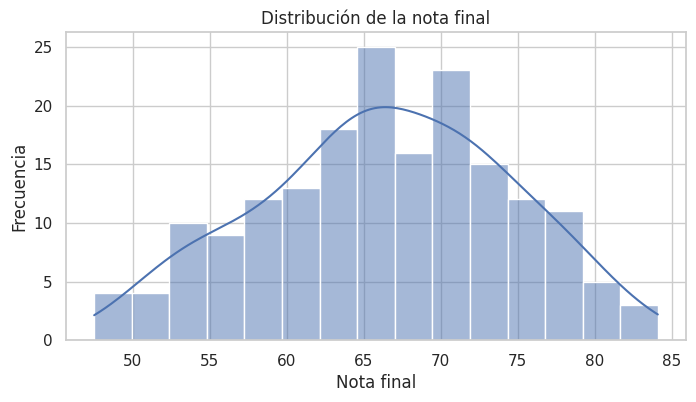

In [77]:
# Distribución de la nota final
plt.figure(figsize=(8, 4))
sns.histplot(df["nota_final"], bins=15, kde=True)
plt.title("Distribución de la nota final")
plt.xlabel("Nota final")
plt.ylabel("Frecuencia")
plt.show()


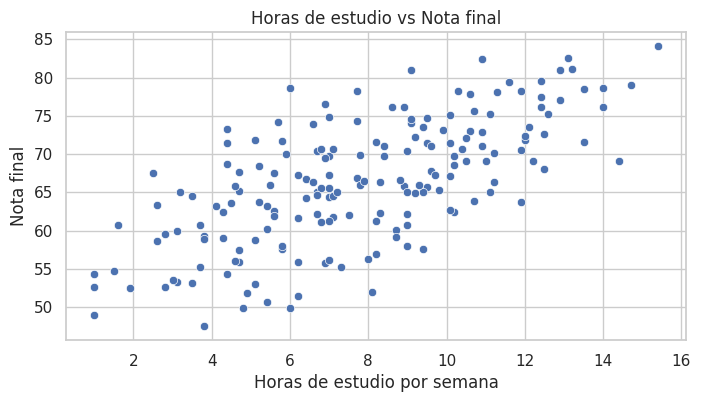

In [78]:
# Relación entre horas de estudio y nota final
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x="horas_estudio_semana", y="nota_final")
plt.title("Horas de estudio vs Nota final")
plt.xlabel("Horas de estudio por semana")
plt.ylabel("Nota final")
plt.show()


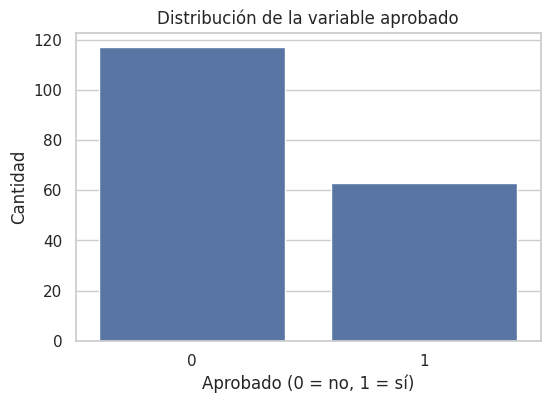

Proporción de aprobación:
aprobado
0    0.65
1    0.35
Name: proportion, dtype: float64


In [79]:
# Conteo de aprobados y no aprobados
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="aprobado")
plt.title("Distribución de la variable aprobado")
plt.xlabel("Aprobado (0 = no, 1 = sí)")
plt.ylabel("Cantidad")
plt.show()

print("Proporción de aprobación:")
print(df["aprobado"].value_counts(normalize=True).sort_index())


## 5. Seleccionar variables de entrada y salida

Un error común en estudiantes principiantes es mezclar la variable objetivo con las variables predictoras.

### En este laboratorio haremos dos tareas:
- **Modelo 1:** predecir `nota_final` usando regresión lineal.
- **Modelo 2:** predecir `aprobado` usando regresión logística.

Usaremos el mismo conjunto de predictores en ambos modelos.


In [80]:
features = [
    "horas_estudio_semana",
    "asistencia_pct",
    "tareas_entregadas",
    "promedio_quices",
    "nota_proyecto",
    "participacion_clase",
    "uso_plataforma_min_semana",
    "tutorias_asistidas",
    "promedio_prev"
]

X = df[features]

y_reg = df["nota_final"]   # objetivo continuo
y_clf = df["aprobado"]     # objetivo binario

print("Dimensión de X:", X.shape)
print("Dimensión de y_reg:", y_reg.shape)
print("Dimensión de y_clf:", y_clf.shape)


Dimensión de X: (180, 9)
Dimensión de y_reg: (180,)
Dimensión de y_clf: (180,)


## 6. Separar datos de entrenamiento y prueba

### ¿Por qué se hace esta división?
Porque el modelo debe aprender con una parte de los datos (**train**) y ser evaluado con otra parte que **no vio antes** (**test**).

Esto nos ayuda a responder una pregunta clave:

> ¿El modelo realmente generaliza o solo memorizó los datos?

Usaremos:
- **80% entrenamiento**
- **20% prueba**


In [81]:
# Para regresión lineal
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Para regresión logística
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Train regresión:", X_train_reg.shape, y_train_reg.shape)
print("Test  regresión:", X_test_reg.shape, y_test_reg.shape)
print("Train clasificación:", X_train_clf.shape, y_train_clf.shape)
print("Test  clasificación:", X_test_clf.shape, y_test_clf.shape)


Train regresión: (144, 9) (144,)
Test  regresión: (36, 9) (36,)
Train clasificación: (144, 9) (144,)
Test  clasificación: (36, 9) (36,)


# Parte A. Regresión lineal

La **regresión lineal** se usa cuando queremos predecir una **cantidad numérica**.

En este caso, la variable objetivo es:

- `nota_final`

La idea del modelo es encontrar una combinación de variables que permita estimar la nota final de cada estudiante.


In [82]:
# ============================================================
# PASO 3. Entrenar el modelo de regresión lineal
# ============================================================

modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_reg, y_train_reg)

print("Modelo entrenado correctamente.")


Modelo entrenado correctamente.


In [83]:
# Predicciones sobre el conjunto de prueba
pred_reg = modelo_lineal.predict(X_test_reg)

resultados_reg = pd.DataFrame({
    "valor_real": y_test_reg.values,
    "prediccion": np.round(pred_reg, 2)
})

resultados_reg.head(10)


,valor_real,prediccion
0,68.7,61.76
1,79.5,75.51
2,63.2,62.15
3,69.8,70.80
4,65.9,61.33
5,59.5,52.14
6,47.5,57.23
7,70.7,68.86
8,81.1,78.14
9,53.6,52.82


In [84]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=resultados_reg)

https://docs.google.com/spreadsheets/d/1sFnwI3acdpbDTBRngTIfcxaWvtSHUVK_h93QtFZImTk/edit#gid=0


## 7. Evaluar la regresión lineal

Usaremos tres métricas importantes:

- **MAE (Mean Absolute Error):** error promedio absoluto.
- **RMSE (Root Mean Squared Error):** error cuadrático medio.
- **R²:** proporción de variabilidad explicada por el modelo.

### ¿Cómo interpretar?
- **MAE y RMSE**: mientras más bajos, mejor.
- **R²**: mientras más cercano a 1, mejor.


In [85]:
# Importamos la función actualizada para RMSE si es necesario o usamos numpy
from sklearn.metrics import root_mean_squared_error

mae = mean_absolute_error(y_test_reg, pred_reg)
rmse = root_mean_squared_error(y_test_reg, pred_reg)
r2 = r2_score(y_test_reg, pred_reg)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2  : {r2:.3f}")

MAE : 3.972
RMSE: 4.995
R2  : 0.567


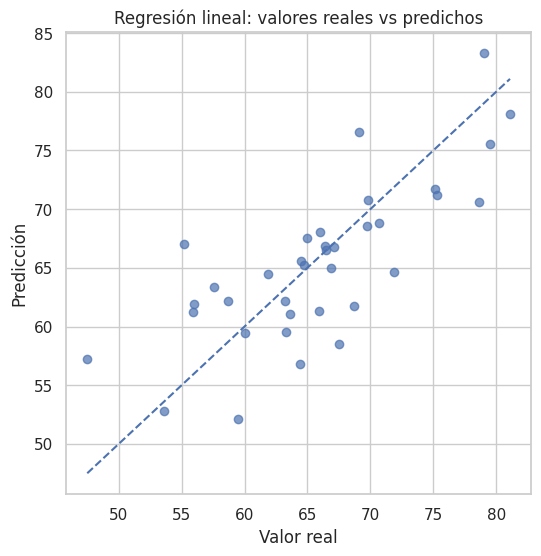

In [86]:
# Visualización: valores reales vs predichos
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, pred_reg, alpha=0.7)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         linestyle="--")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Regresión lineal: valores reales vs predichos")
plt.show()


In [87]:
# Interpretación de coeficientes
coeficientes = pd.DataFrame({
    "variable": features,
    "coeficiente": modelo_lineal.coef_
}).sort_values("coeficiente", ascending=False)

coeficientes


,variable,coeficiente
0,horas_estudio_semana,1.785620
7,tutorias_asistidas,1.057306
2,tareas_entregadas,0.824642
5,participacion_clase,0.766299
3,promedio_quices,0.159205
1,asistencia_pct,0.141834
4,nota_proyecto,0.078429
8,promedio_prev,0.062646
6,uso_plataforma_min_semana,0.012202


### Preguntas de interpretación
1. ¿Qué variables tienen coeficientes más altos?
2. ¿Tiene sentido desde el punto de vista académico?
3. ¿Hay variables que parecen aportar poco al modelo?


# Parte B. Regresión logística

La **regresión logística** se usa cuando la variable objetivo es **binaria**.

Aquí queremos predecir:

- `aprobado` → 0 o 1

Aunque su nombre contiene la palabra *regresión*, este modelo se usa para **clasificación**.


In [88]:
# ============================================================
# PASO 4. Entrenar el modelo de regresión logística
# ============================================================

modelo_logistico = LogisticRegression(max_iter=500)
modelo_logistico.fit(X_train_clf, y_train_clf)

print("Modelo logístico entrenado correctamente.")


Modelo logístico entrenado correctamente.


In [89]:
# Predicción de clases
pred_clf = modelo_logistico.predict(X_test_clf)

# Predicción de probabilidades
prob_clf = modelo_logistico.predict_proba(X_test_clf)[:, 1]

resultados_clf = pd.DataFrame({
    "real": y_test_clf.values,
    "predicho": pred_clf,
    "probabilidad_aprobar": np.round(prob_clf, 3)
})

resultados_clf.head(10)


,real,predicho,probabilidad_aprobar
0,0,0,0.125
1,1,0,0.362
2,1,1,0.732
3,0,0,0.216
4,0,0,0.042
5,1,0,0.446
6,1,1,0.594
7,0,0,0.015
8,0,0,0.014
9,1,0,0.434


## 8. Evaluar la regresión logística

Usaremos estas métricas:

- **Accuracy:** proporción de aciertos.
- **Precision:** de los que el modelo predijo como positivos, cuántos realmente lo eran.
- **Recall:** de los positivos reales, cuántos detectó el modelo.
- **F1-score:** equilibrio entre precision y recall.
- **ROC AUC:** capacidad del modelo para separar clases.

### Nota importante
Si el dataset está desbalanceado, no conviene mirar solo accuracy.


In [90]:
acc = accuracy_score(y_test_clf, pred_clf)
prec = precision_score(y_test_clf, pred_clf, zero_division=0)
rec = recall_score(y_test_clf, pred_clf, zero_division=0)
f1 = f1_score(y_test_clf, pred_clf, zero_division=0)
auc = roc_auc_score(y_test_clf, prob_clf)

print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC AUC  : {auc:.3f}")


Accuracy : 0.750
Precision: 0.700
Recall   : 0.538
F1-score : 0.609
ROC AUC  : 0.886


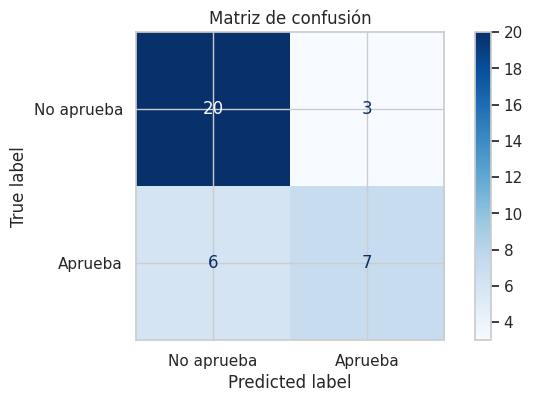

In [91]:
cm = confusion_matrix(y_test_clf, pred_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No aprueba", "Aprueba"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión")
plt.show()


In [92]:
# Coeficientes del modelo logístico
coef_log = pd.DataFrame({
    "variable": features,
    "coeficiente_logistico": modelo_logistico.coef_[0]
}).sort_values("coeficiente_logistico", ascending=False)

coef_log


,variable,coeficiente_logistico
0,horas_estudio_semana,0.590572
2,tareas_entregadas,0.353853
5,participacion_clase,0.303930
7,tutorias_asistidas,0.211089
1,asistencia_pct,0.060633
4,nota_proyecto,0.045047
8,promedio_prev,0.041900
3,promedio_quices,0.031414
6,uso_plataforma_min_semana,0.003201


## 9. Comparación conceptual: lineal vs logística

| Aspecto | Regresión lineal | Regresión logística |
|---|---|---|
| Tipo de salida | Numérica continua | Probabilidad / clase |
| Ejemplo en este laboratorio | `nota_final` | `aprobado` |
| Métricas típicas | MAE, RMSE, R² | Accuracy, Precision, Recall, F1, AUC |
| Uso principal | Predicción de cantidades | Clasificación binaria |

### Idea clave
No elegimos el modelo por costumbre, sino por el **tipo de variable objetivo**.


## 10. Actividad guiada para el estudiante

Realiza las siguientes tareas y documenta tus respuestas:

1. Cambia la sección (`A`, `B`, `C`, `D`) y vuelve a ejecutar el notebook.
2. Compara:
   - promedio de `nota_final`
   - porcentaje de `aprobado`
   - desempeño de la regresión lineal
   - desempeño de la regresión logística
3. Responde:
   - ¿qué sección obtuvo mejor R²?
   - ¿en cuál sección el modelo logístico clasificó mejor?
   - ¿qué variables aparecen con mayor peso en ambos modelos?


## 11. Ejercicios de profundización

### Ejercicio 1
Elimina una variable del conjunto de predictores y observa si el desempeño mejora o empeora.

### Ejercicio 2
Agrega una nueva visualización:
- mapa de calor de correlación
- boxplot por `aprobado`
- gráfico de barras de coeficientes

### Ejercicio 3
Prueba una regla de decisión distinta:
- en lugar de usar 0.5 como umbral de clasificación, prueba con 0.4 o 0.6

### Ejercicio 4
Explica con tus propias palabras:
- cuándo usar regresión lineal
- cuándo usar regresión logística
- por qué no debemos evaluar clasificación solo con accuracy


## 12. Conclusión del laboratorio

En este laboratorio aprendiste a:

- cargar y revisar un dataset,
- diferenciar una variable continua de una binaria,
- entrenar un modelo de **regresión lineal**,
- entrenar un modelo de **regresión logística**,
- evaluar ambos modelos con métricas adecuadas,
- interpretar resultados de forma básica.

### Idea final
El aprendizaje automático no consiste solo en ejecutar código.  
Consiste en **entender el problema, elegir el modelo correcto y justificar los resultados**.
